In [1]:
import nltk
nltk.download('vader_lexicon')
nltk.download('stopwords')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Pratham\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pratham\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [3]:
import pandas as pd

df = pd.read_csv("sentimentdataset.csv")
df.head()


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [7]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)      # remove emojis & punctuation
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text

df['clean_text'] = df['Text'].apply(clean_text)


In [8]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df['vader_score'] = df['clean_text'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)


In [9]:
def classify(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Predicted_Sentiment'] = df['vader_score'].apply(classify)


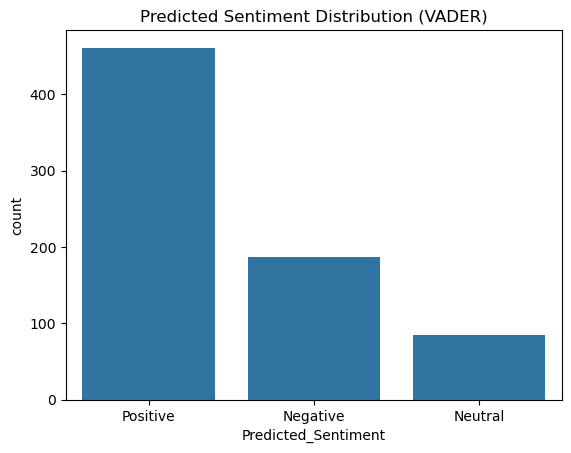

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Predicted_Sentiment')
plt.title("Predicted Sentiment Distribution (VADER)")
plt.show()


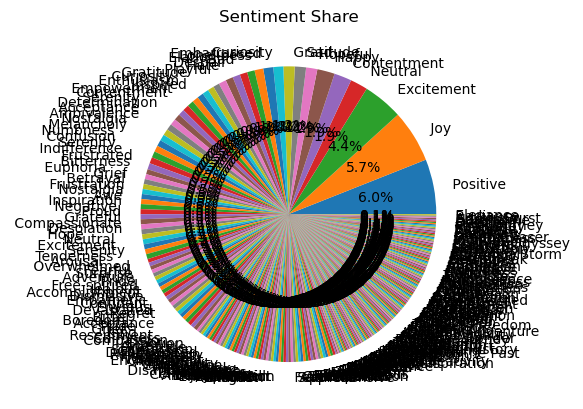

In [11]:
df['Sentiment'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Sentiment Share")
plt.ylabel("")
plt.show()


In [ ]:
%pip install wordcloud


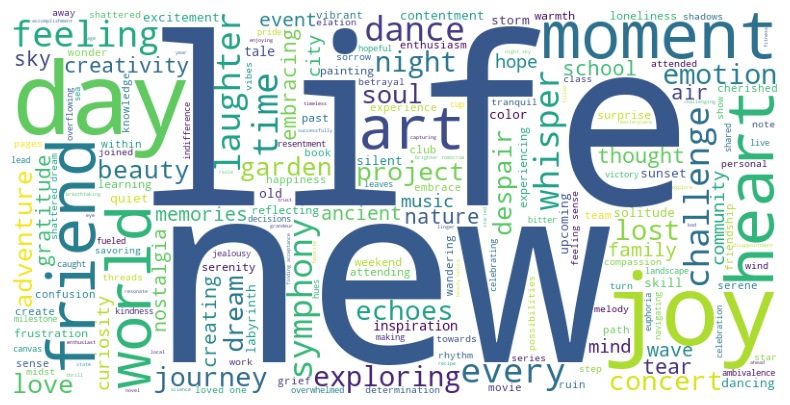

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(" ".join(df['clean_text']))

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.show()


In [15]:
df['Predicted_Sentiment'].value_counts(normalize=True) * 100


Predicted_Sentiment
Positive    62.978142
Negative    25.546448
Neutral     11.475410
Name: proportion, dtype: float64